# Intro

Efter at i nu er kommet hjem fra feltarbejde er det tid til at analysere de GPS-data i har indsamlet. For at hjælpe jer godt i gang har vi skrevet noget kode der kan bearbejde jeres data på forskellige måder, og denne **Jupyter Notebook** indeholder en masse praktiske eksempler på hvordan koden kan bruges.

# 1. Sådan indhenter du dine GPS-data

Til denne notebook har vi indsamlet en lille håndfuld test-data for at illustrere hvordan koden virker. Disse data er ligger undermappen */Data/GPS_Waypoints* i samme filsystem som denne notebook. Test-dataene findes i to forskellige formater som er de samme som dem i kan eksportere ud fra jeres mobiltelefon. Før vi kan analysere vores GPS-punkter, skal vi først hente dem ind i Python. Til det formål har vi lavet to funktioner *gpxLoader* og *csvLoader* der hver især læser en GPS-fil i et specifikt format og henter den relevante information fra dem. Lad os prøve at bruge disse funktioner til at indhente nogle test-data vi har lavet. 

## 1.1 Indhent en .gpx fil

Vi kan indhente GPS-data fra en .gpx fil ved at bruge funktionen *gpxLoader* på denne måde:

In [ ]:
# Importer vores funktion
from Functions.utils import gpxLoader

# Indhent vores .gpx fil
df = gpxLoader('Data/GPS_Waypoints/GPS_points_example.gpx')

## 1.2 Indhent en .csv fil

Vi kan også indhente GPS-data fra en .csv fil ved at bruge funktionen *csvLoader* på denne måde

In [1]:
# Importer vores funktion
from Functions.utils import csvLoader

# Indhent vores .csv fil
df = csvLoader('Data/GPS_Waypoints/GPS_waypoints_waypointLite.csv')

## 1.3 Hvad hvis vi har indtastet vores GPS-data manuelt? 

Hvis i af hvad end årsager har måtte indtaste jeres GPS-koordinater manuelt i en Microsoft Excel fil eller et lignende format, skal i sørge for at i har givet datasøjlerne et navn som funktionerne ovenfor kan genkende. I kan indsætte navnene nedenfor på de datasøjler hvor det er relevant: 

Name, Timestamp, Latitude, Longitude, Altitude_MSL, Altitude_Ellipsoid, Accuracy

## 1.4 Hvad hvis vi har indsamlet forskellige data og gerne vil samle dem i én fil? 

Hvis i har indsamlet jeres data hver for sig og derfor har målt forskellige GPS-punkter der er gemt i hver deres fil, kan i splejse dem sammen til blot én fil i denne Notebook. 
Dette kan gøres ved først at importere alle jeres individuelle datafiler (både .gpx og .csv) og derefter bruge funktionen *pdMerger* som den er illustreret i koden-bidden nedenfor. Funktionen kan sammensplejse et ubegrænset antal datafiler med hver deres forskellige mængder af variable, og indsætter automatisk tomme fyldeværdier på pladsen hvor en variabel mangler for et givent GPS-punkt.

In [3]:
# Importer vores funktion
from Functions.utils import pdMerger

# Indhent vores filer
df1 = gpxLoader('Data/GPS_Waypoints/GPS_points_example.gpx')
df2 = csvLoader('Data/GPS_Waypoints/GPS_points_example.csv')

# Lav en samlet liste med deres dataframes. Hvis i har flere kan i blot indsætte dem efter kommaet i listen nedenfor
df_list = [df1, df2]

#Sammensplejs de to dataframes 
df_merged = pdMerger(df_list)

## 2. Sådan får du et overblik af dine GPS-data

Inden vi begynder at plotte vores GPS-data, vil det være godt at danne os et overblik om hvad informationer de rent faktisk indeholder. Vi kan bede Python vise os noget mere info om vores data ved at bruge følgende kommando: 

In [2]:
# Print noget forklaringstekst
print("--- Vores GPS-datafil inkluderer disse variabler ---\n")

# Se hvilke variabler der er inkluderet i .gpx datafilen
df.info()

--- Vores GPS-datafil inkluderer disse variabler ---

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Name          88 non-null     str     
 1   Timestamp     88 non-null     str     
 2   Altitude_MSL  88 non-null     float64 
 3   Accuracy      88 non-null     float64 
 4   geometry      88 non-null     geometry
dtypes: float64(2), geometry(1), str(2)
memory usage: 3.6 KB


Som vi kan se fra det ovenstående resultat, indeholder vores eksempel .gpx fil 6 forskellige variable der hver har 4 datapunkter. Afhængigt af din telefons operativsystem og hvilken version af *GPS Waypoints* appen du har brugt til at lave din GPS-fil, har du måske kun nogle af disse variable inkluderet i den. Uanset hvad vil de dog altid inkludere *Altitude_MSL* og *geometry* hvilket er de vigtigste for os. 

Variablen "*Altitude_MSL*" lader til at være interessant, så lad os undersøge denne nærmere.

In [3]:
# Print noget forklaringstekst
print("--- Vores GPS-datafil inkluderer denne variabel kaldt ele ---\n")

# Vis værdierne for en specifik variabel
df.Altitude_MSL

--- Vores GPS-datafil inkluderer denne variabel kaldt ele ---



0     14.565601
1     16.546658
2     15.006374
3      8.966396
4     12.110073
        ...    
83    23.323452
84    16.011562
85    14.950597
86    10.794582
87    15.750515
Name: Altitude_MSL, Length: 88, dtype: float64

I resultatet oven for kan vi se at alle GPS-punkterne har en højde der ligger inde for det samme 5m spænd. Til sidst er vi måske interesseret i at undersøge hvilket projektion og koordinatsystem vores GPS-data er givet i.

In [4]:
# Print noget forklaringstekst
print("--- Vores GPS-datafil er i denne projektion ---\n")

# Se hvad projektion vores data er i
df.crs

--- Vores GPS-datafil er i denne projektion ---



<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

Fra resultatet ovenfor kan vi se at vores GPS-data er givet i projektionen **EPSG:4326** som er defineret i et (Lat,Lon) koordinatsystem med enheden **degree**. Prøv at Google denne projektion. Hvad er der specielt ved den og til hvilke formål ville man bruge den? 

# 3. Sådan plotter du dine GPS-data på et danmarkskort

Efter at have dannet os et overblik af vores datafil ville det nu være oplagt at plotte GPS-punkterne i den. GPS-punkter er svære at fortolke uden noget ekstra information der giver et indtryk af skalaen mellem dem (distance, højde, osv.), så lad os plotte dem oven på et kort af Danmarks omkreds og se hvor de ligger henne. Vi kan gøre dette ved hjælp af vores funktion plotDKMap således: 

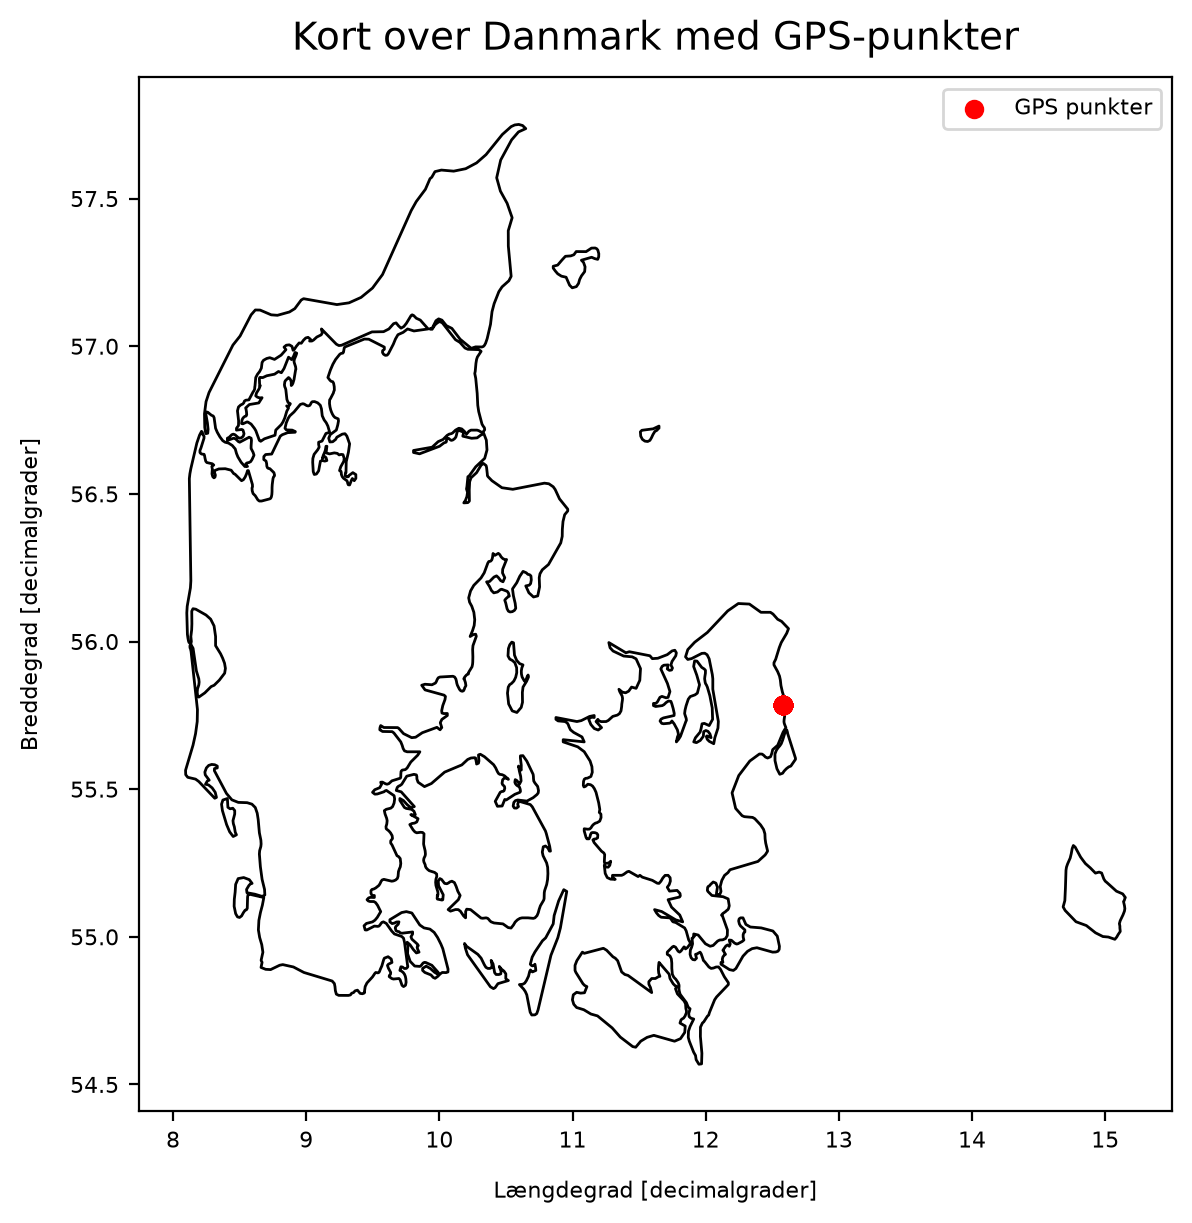

In [5]:
# Importer vores funktion
from Functions.utils import plotDKMap

# # # Plot vores GPS-data
#
# Navn på vores GPS-data                         = df
# Navn på billedet vi gerne vil gemme            = 'Figur1.pdf'
# Zoom ind på GPS-punkterne?                     = False
# Vis navnene på GPS-punkterne?                  = False
# Farvekod GPS-punkterne efter deres højdeværdi? = False 
#
plotDKMap(dataframe         = df, 
          output_file_name  = 'Figur1.pdf', 
          zoom              = False,
          name              = False, 
          height            = False)

Fra dette kort kan vi se at de fire GPS-punkter ligger på Sjælland omtrent der hvor DTU også ligger. Vi har gemt denne figur som en pdf hvilket er rigtig smart at bruge hvis man skal indsætte den i et Overleaf dokument, og den ligger i folderen kaldt "*Results*". Dette kort er godt til at give os et hurtigt overblik, men dets skala er så stort at de ligner at de fire punkter ligger oven i hinanden. Lad os nu prøve at lave det samme plot igen, men denne gang zoome ind omkring de fire GPS-punkter.

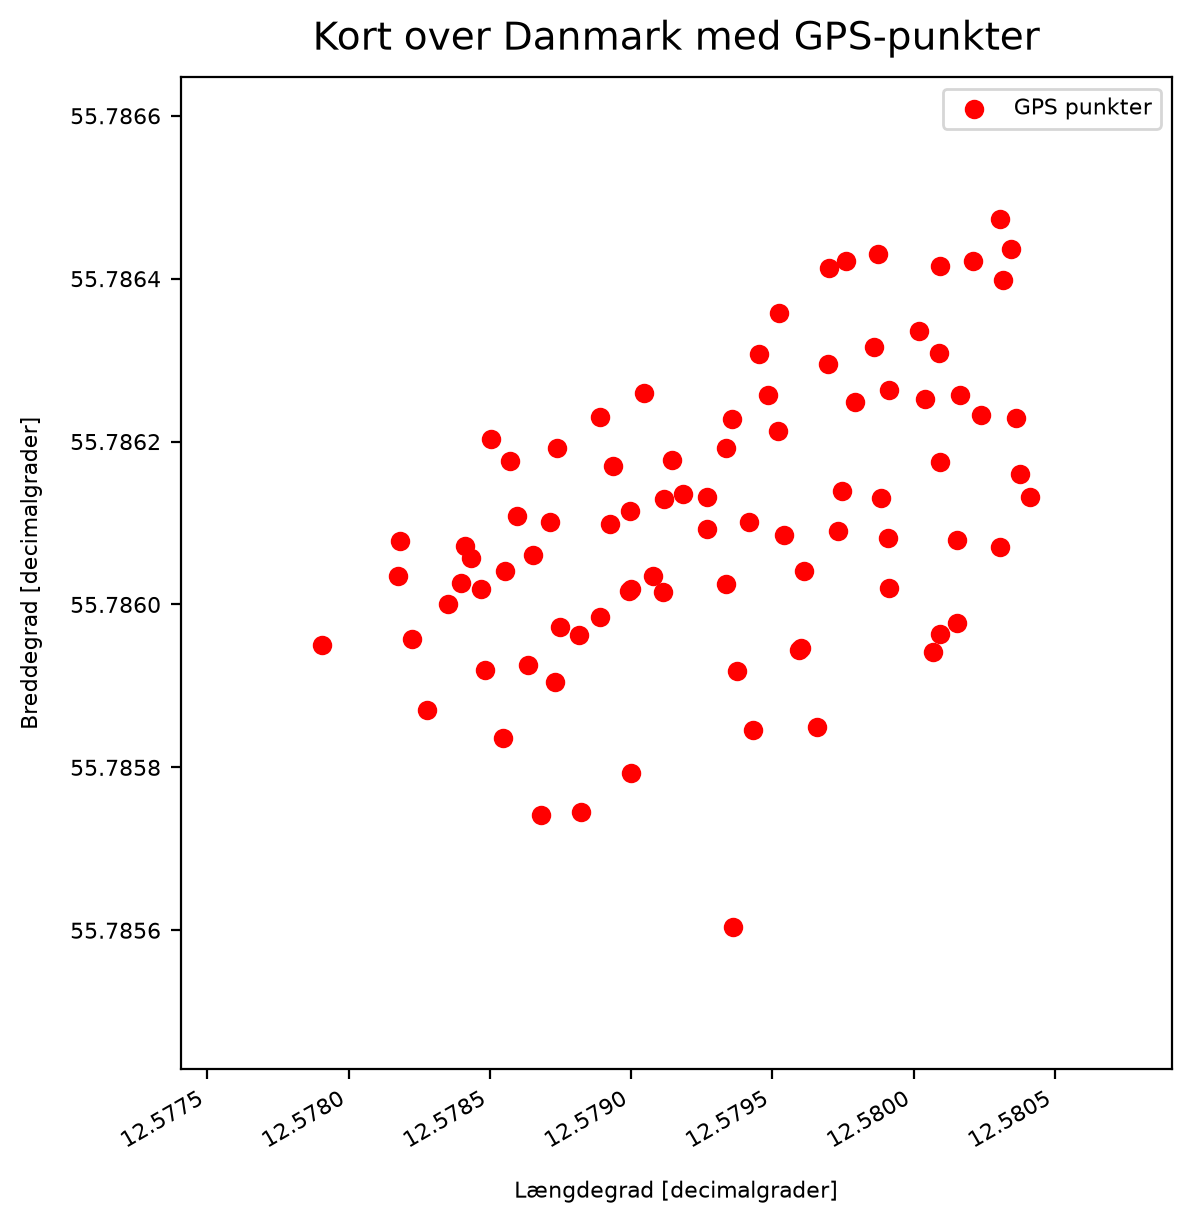

In [6]:
# # # Plot vores GPS-data
#
# Navn på vores GPS-data                         = df
# Navn på billedet vi gerne vil gemme            = None dvs. gem den ikke
# Zoom ind på GPS-punkterne?                     = True 
# Vis navnene på GPS-punkterne?                  = False
# Farvekod GPS-punkterne efter deres højdeværdi? = False 
#
plotDKMap(dataframe         = df, 
          output_file_name  = None, 
          zoom              = True,
          name              = False, 
          height            = False)

Fra dette plot kan vi se at de fire punkter ikke ligger oven i hinanden men i stedet er spredt ud i det der ligner en firkant. Denne figur viser bedre hvor de forskellige punkter ligger i forhold til hinanden, men den er ikke helt god siden vi ved ikke hvilke punkter der er hvilke eller hvad deres højdeværdier er. Lad os derfor prøve at lave den samme figur igen, men denne gang hvor vi også plotter navnet på de forskellige GPS-punkter og farvekoder dem efter hvor højt de ligger over middel havniveau. 

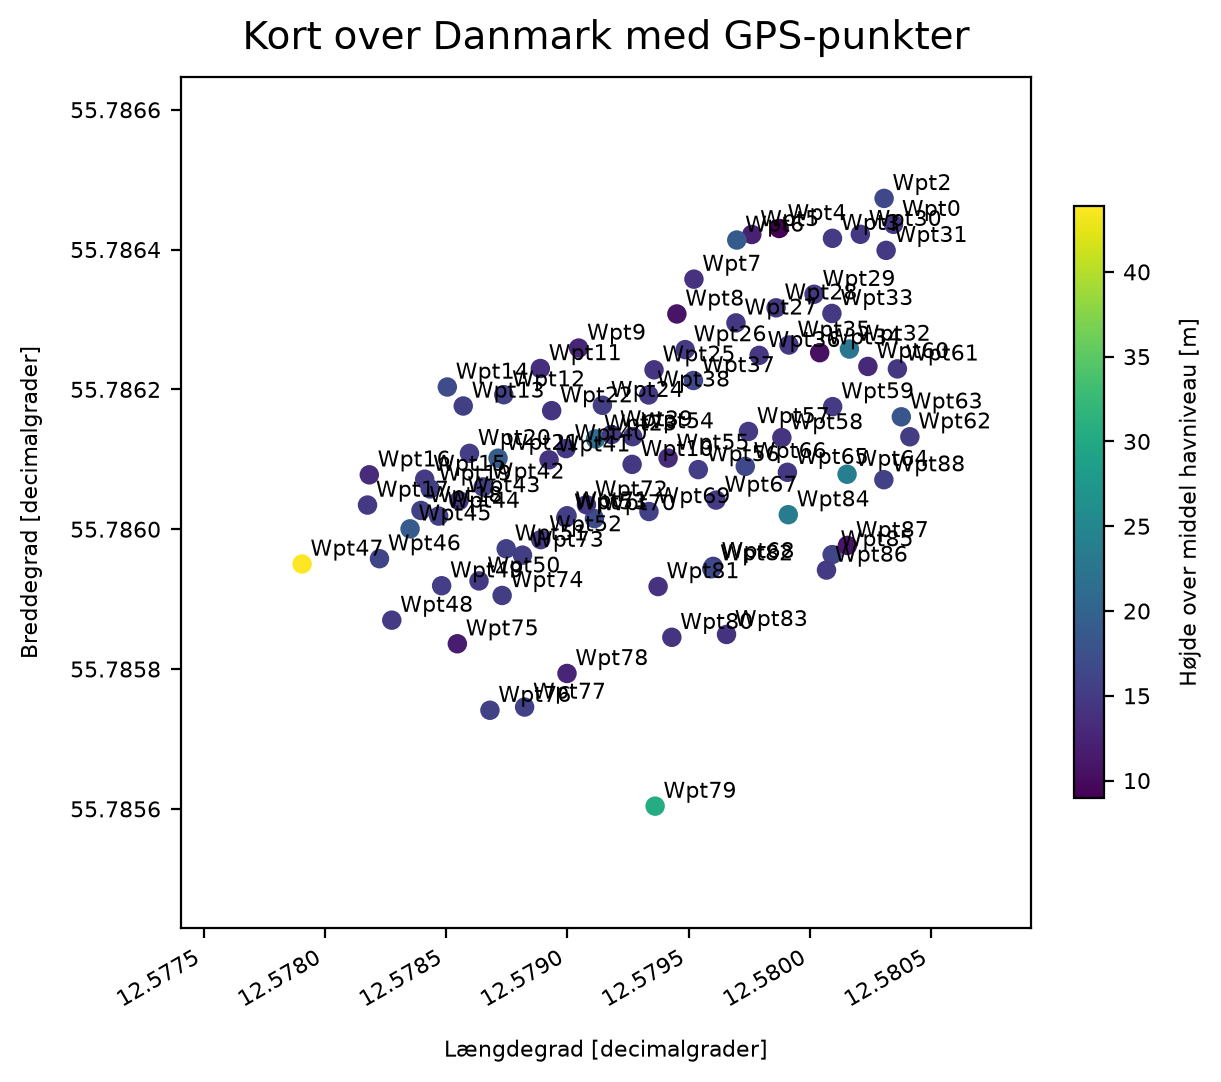

In [7]:
# # # Plot vores GPS-data
#
# Navn på vores GPS-dats                         = df
# Navn på billedet vi gerne vil gemme            = 'Figur2.pdf'
# Zoom ind på GPS-punkterne?                     = True 
# Vis navnene på GPS-punkterne?                  = True
# Farvekod GPS-punkterne efter deres højdeværdi? = True
#  
plotDKMap(dataframe         = df, 
          output_file_name  = 'Figur2.pdf', 
          zoom              = True,
          name              = True, 
          height            = True)

Fra denne figur kan vi nu meget tydeligt se hvilke GPS-punkter der er hvilke og hvordan højden over den rute vi har taget, ændrer sig fra sted til sted. Vi har ligeledes gemt denne figur under folderen kaldt "*Results*". 

# 4. Sådan plotter du dine GPS-punkter på et højdekort

Nøjagtigheden af de GPS-punkter vi selv har indsamlet med vores mobiltelefoner, afhænger af hvor godt et signal vi havde på det tidspunkt vi tog dem. Hvis vi indsamlede dem tæt på høje træer/bygninger eller anden form for overdække er der en god chance for at vores GPS-signal blev forstyrret og at vi derfor opsamlede nogle usikre højdeværdier. Det vil derfor være interessant at sammenligne højdeværdierne på vores GPS-punkter med et referencehøjdekort. Dataforsyningen har mange forskellige landkort frit tilgængelige på deres hjemmeside, og specielt de data der hedder **Danmarks Højdemodel - Overflade** og **Danmarks Højdemodel - Terræn** ville være meget relevante for os. I denne notebook har vi inkluderet et overflade-kort og et terræn-kort som dækker det samme område som vores eksempel GPS-punkter. Disse findes henholdsvis i undermapperne "*Data/Surfacemap/*" og "*Data/Terrainmap/*". 

Lad os prøve at plotte disse to kort ved hjælp af vores funktion 

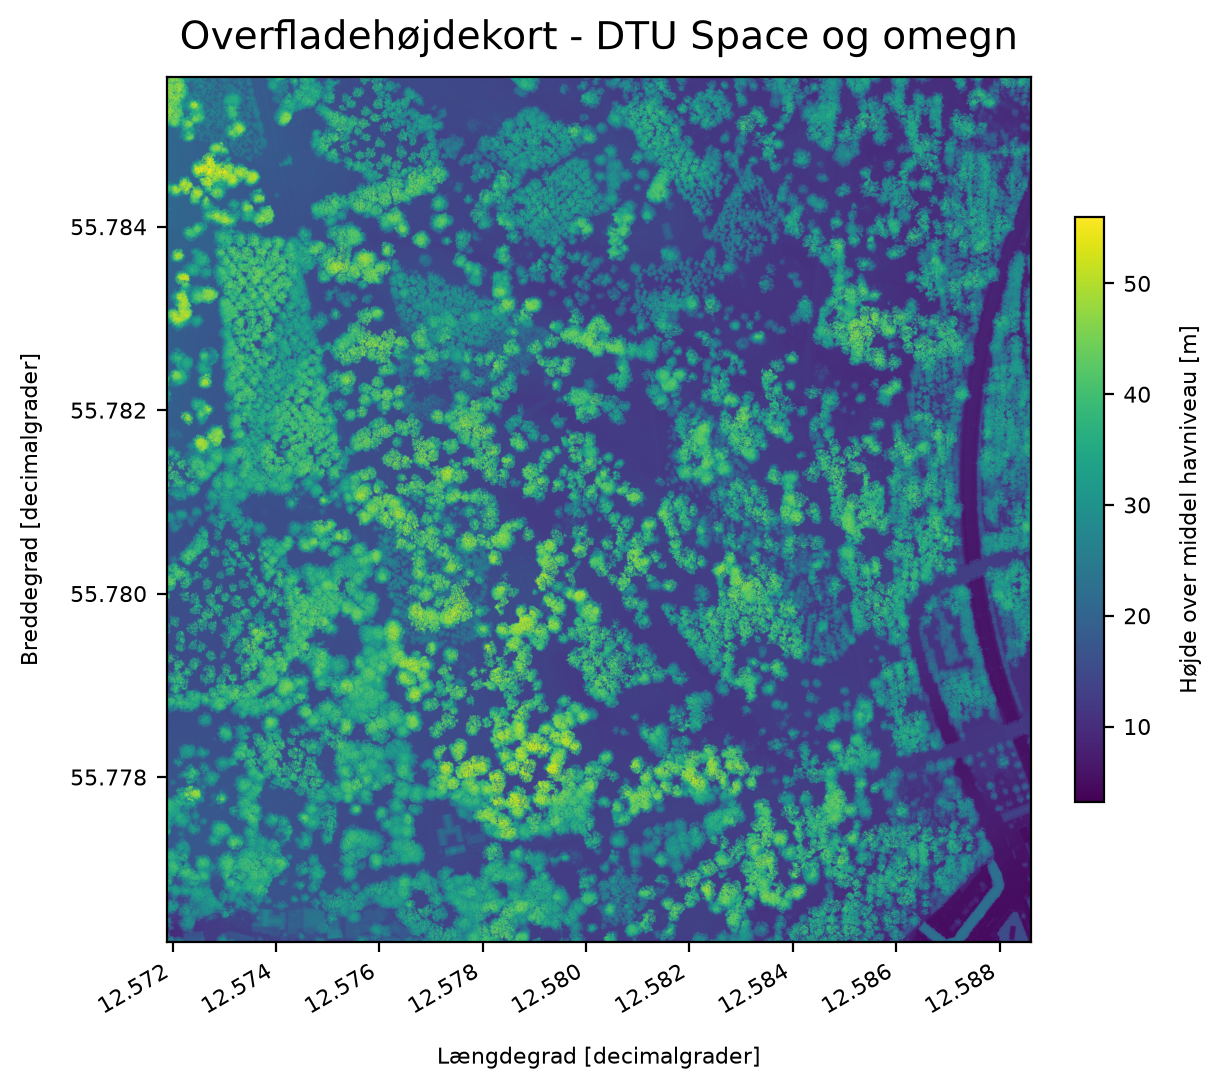

In [10]:
# Importer vores funktion
from Functions.utils import plotHeightMap

# # # Plot et overfladehøjdekort hvor vi selv definerer titlen på kortet
#
# Navn på kortet vi vil tegne           = "Data/Surfacemap/DSM_1km_6187_720.tif"
# Navn på GPS-data vi vil plotte ovenpå =  None, dvs de skal ikke plottes
# Navn på billedet vi gerne vil gemme   =  None
# Titlen på figuren vi tegner           = "Overfladehøjdekort - DTU Space og omegn"
# Vis navnene på GPS-punkterne?         = False
# Zoom ind på højdekortet               = True
#
plotHeightMap(mapfile           = "Data/Surfacemap/DSM_1km_6187_724.tif", 
              dataframe         = None,
              output_file_name  = None, 
              ptitle            = "Overfladehøjdekort - DTU Space og omegn",
              name              = False,
              zoom              = True)

Fra dette plot kan vi se at overflade højdekortene har så høj detaljegrad at individuelle bygninger og endda træer står ud fra baggrunden i billedet. Vi kan se at det meste af billedet har en højde et sted mellem 30m til 50m, men at der også er et lille område med en overfladehøjde på lidt over 110m! Dette meget lille område med en meget høj værdi ligger i 4. kvadrant af DTU tæt på den lokale Netto. Hvis du kender lidt til dette område af DTU, virker denne højde så realistisk? Hvad, hvis noget, kan have denne højde? Og hvis det ikke virker realistisk, hvad kan så forklare fejlen? Uanset hvad er det tydeligt at denne slags kort afspejler den menneskelige verden godt, og indeholder relevante højdeinformationer hvis man er interesseret i at opfange hvordan infrastruktur og bygninger kan ændre det lokale landskab. 

Lad os nu herefter prøve at plotte terrænhøjdekortet for det samme område og undersøge hvad forskel der måtte være mellem de to typer kort. 

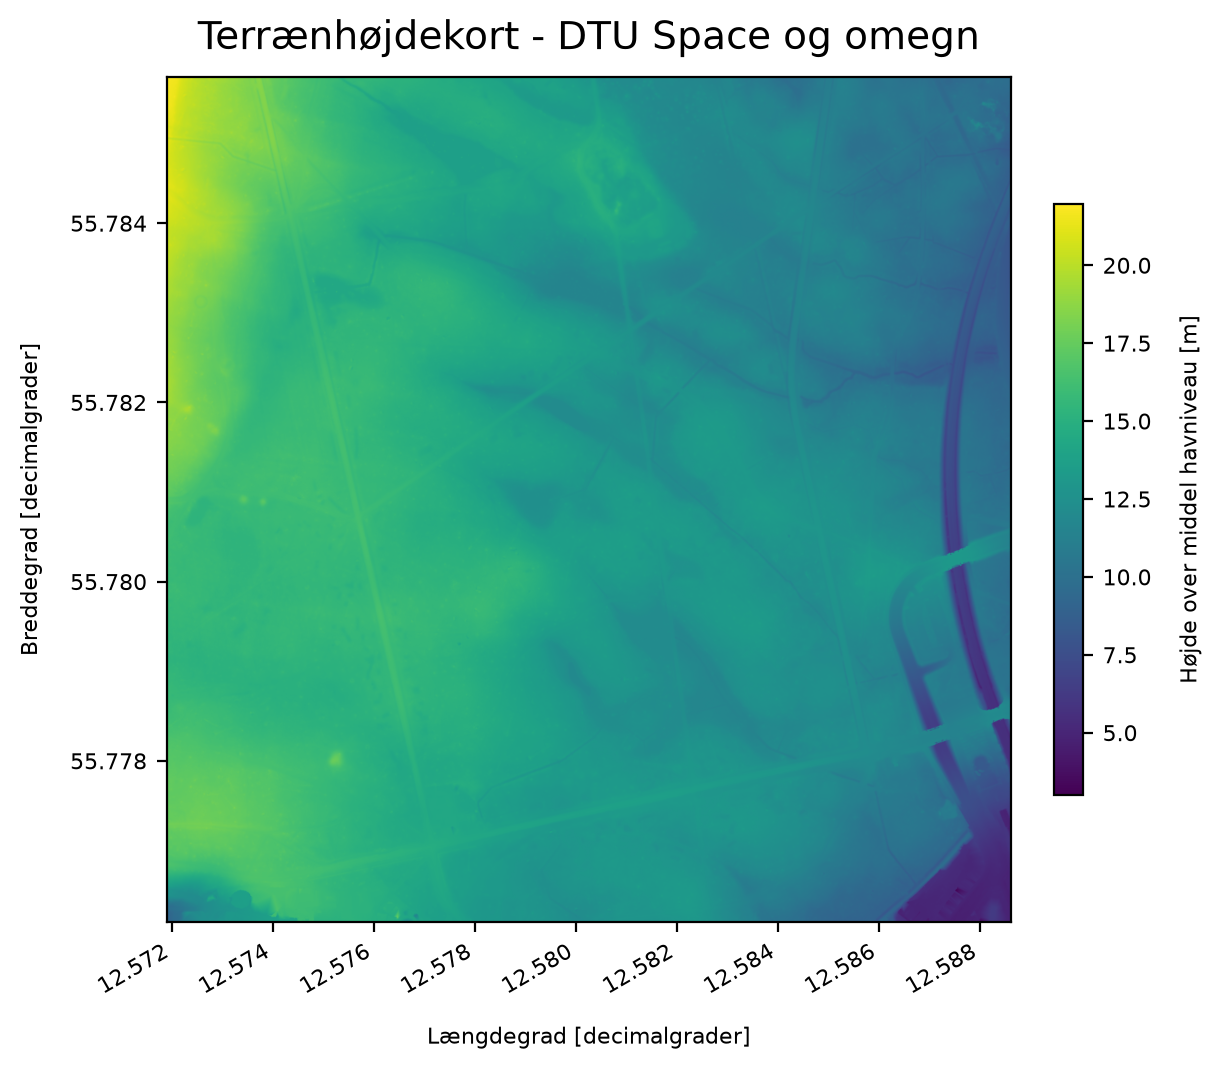

In [ ]:
# # # Plot et overfladehøjdekort hvor vi selv definerer titlen på kortet
#
# Navn på kortet vi vil tegne           = "Data/Terrainmap/DTM_1km_6187_720.tif"
# Navn på GPS-data vi vil plotte ovenpå =  None, dvs de skal ikke plottes
# Navn på billedet vi gerne vil gemme   =  None
# Titlen på figuren vi tegner           = "Terrænhøjdekort - DTU Space og omegn"
# Vis navnene på GPS-punkterne?         = False
# Zoom ind på højdekortet               = True
#
plotHeightMap(mapfile           = "Data/Terrainmap/DTM_1km_6188_724.tif", 
              dataframe         = None,
              output_file_name  = None, 
              ptitle            = "Terrænhøjdekort - DTU Space og omegn",
              name              = False,
              zoom              = True)

Fra dette plot kan vi se at højdeværdierne i et terrænhøjdekort er mere uniforme end dem i et overfladehøjdekort. Det er lettere at se hvordan bakker og dale former landskabet og se hvad den sande gennemsnitshøjde i terrænet er uden at blive distraheret af menneskeskabte ting. Det er dog også tydeligt at hvad end metode man har brugt til at udglatte højderne i området, ikke virker lige godt alle steder. Der ligger mange små klatter med højdeværdier der står ud fra deres omgivelser, og nogle af de skarpe kanter rundt om menneskeskabte ting er udtværede så det er svært at se hvor de starter og stopper. Med disse observationer i mente, hvad tror du styrkerne og svaghederne er for disse to typer kort?

Uanset hvad, lad os nu prøve at plotte vores GPS-punkter oven på disse referencekort for at se hvordan de passer ind i højdebilledet for området.

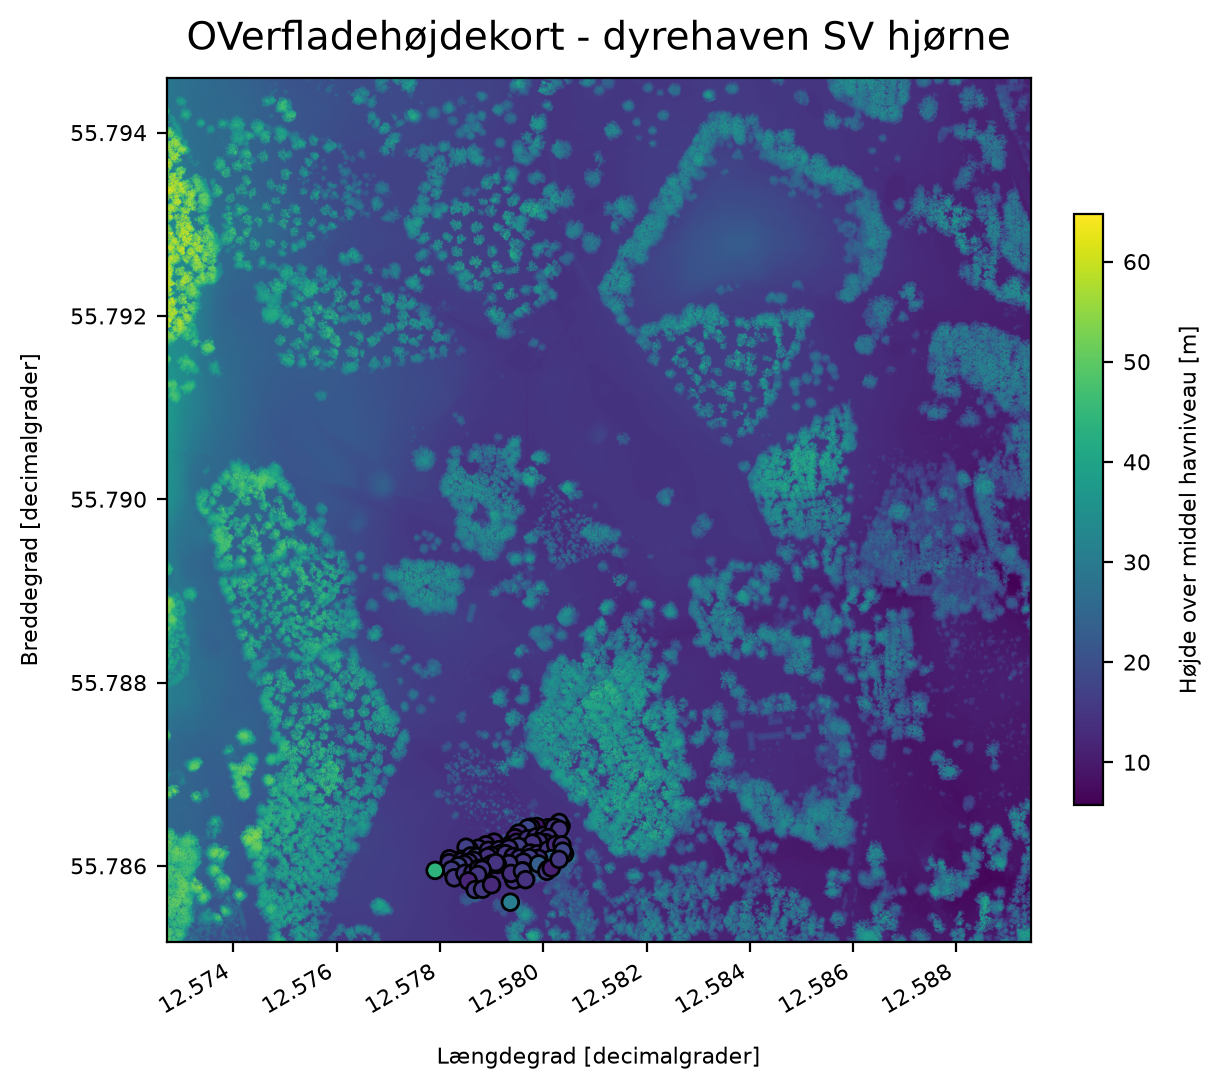

In [16]:
# # # Plot et overfladehøjdekort hvor vi selv definerer titlen på kortet
#
# Navn på kortet vi vil tegne           = "Data/Surfacemap/DSM_1km_6187_720.tif"
# Navn på GPS-data vi vil plotte ovenpå =  df
# Navn på billedet vi gerne vil gemme   =  'Figur3.pdf'
# Titlen på figuren vi tegner           = "Overfladehøjdekort - DTU Space og omegn"
# Vis navnene på GPS-punkterne?         = False
# Zoom ind på højdekortet               = True
#
plotHeightMap(mapfile           = "Data/Surfacemap/DSM_1km_6188_724.tif", 
              dataframe         = df,
              output_file_name  = 'Figur3.pdf', 
              ptitle            = "OVerfladehøjdekort - dyrehaven SV hjørne",
              name              = False,
              zoom              = True)

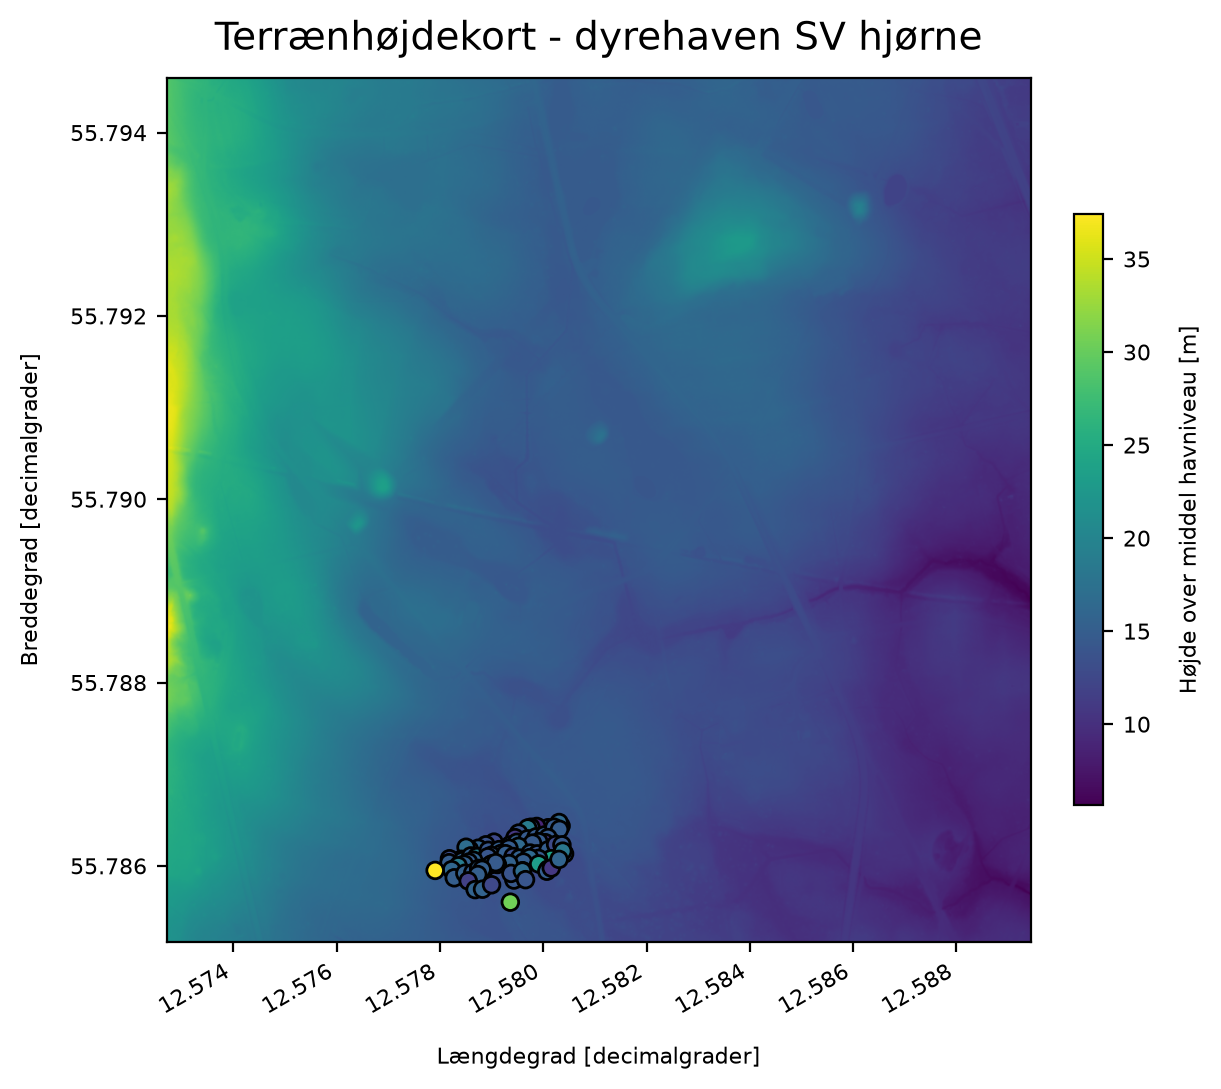

In [15]:
# # # Plot et overfladehøjdekort hvor vi selv definerer titlen på kortet
#
# Navn på kortet vi vil tegne           = "Data/Terrainmap/DTM_1km_6187_720.tif"
# Navn på GPS-data vi vil plotte ovenpå =  df
# Navn på billedet vi gerne vil gemme   =  'Figur4.pdf'
# Titlen på figuren vi tegner           = "Terrænhøjdekort - DTU Space og omegn"
# Vis navnene på GPS-punkterne?         = False
# Zoom ind på højdekortet               = True
#
plotHeightMap(mapfile           = "Data/Terrainmap/DTM_1km_6188_724.tif", 
              dataframe         = df,
              output_file_name  = 'Figur4.pdf', 
              ptitle            = "Terrænhøjdekort - dyrehaven SV hjørne",
              name              = False,
              zoom              = True)

# 5. Sådan finder du refernceværdier for dine GPS data

Figurerne i det tidligere afsnit er gode til at illustrere vores data, men vi kan ikke bruge dem til at lave en statistisk sammenligning mellem dem. For at kunne dette skal vi bruge de eksakte referenceværdier for vores GPS-punkter, og dette kan funktionen *getReferenceHeight* bruges til. Funktionen er smart på den måde at du blot behøver at fortælle den navnet på dine GPS-punkter (*df* i dette eksempel), og funktionen vil derefter automatisk lede alle de referencehøjdekort der ligger i *Data/Surfacemap* og *Data/Terrainmap* mapperne igennem for de relevante data og trække dem ud som en ny variabel. Hvis funktionen ikke kan finde nogle højdekort i mapperne der overlapper med et eller flere af dine GPS-punkter, vil funktionen fortælle dig hvilke punkter der ikke har nogen dækning og i stedet indsætte en fylde-højdeværdi for disse i den nye Data Frame. Vi kan prøve at bruge funktionen til at finde referenceværdier for vores test-data: 

In [14]:
# Importer den speciellavede funtion
from Functions.utils import getReferenceHeight

# Lav en ny DataFrame med reference-højdeværdier lagt på som variablene 'Altitude_Reference_Surface' og 'Altitude_Reference_Terrain'
df_new = getReferenceHeight(df)

# Print info om den nye dataframe 
df_new.info()

WARNING - No relevant surface height map exists for GPS Waypoint(s) [ 1, 2, 3, 4, 5, 6, 7, 8, 9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,
 25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,
 49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,
 73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88], inserting filler value(s)
WARNING - No relevant terrain height map exists for GPS Waypoint(s) [ 1, 2, 3, 4, 5, 6, 7, 8, 9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,
 25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,
 49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,
 73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88], inserting filler value(s)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Name                        88 non-

# 6. Sådan eksporterer du dine GPS-data ud af Python

Efter at have plottet dataene på et kort og indhentet nogle referencehøjdeværdier for dem, kan vi begynde den vigtigste del af vores analyse, nemlig statistikken. Til det formål ville det måske være lettere at have vores GPS-data i et mere lavpraktisk format. Funktionen *pdExport* kan eksportere jeres data ud i .txt, .csv eller .xlsx format hvilket alle kan åbnes i de fleste andre databehandlings-programmer som fx. Microsot Excel. Funktionen bruges på følgende måde til at gemme en kopi af vores test-data i *Results* mappen: 

In [15]:
# Importer funktionen
from Functions.utils import pdExport

# Brug funktionen til at eksportere vores data - vi definerer at vi gerne vil have at output filen skal være i .csv format ved at angive det i navnet på den. 
pdExport(df_new, "Results/test_GPS_points_with_reference_heights.csv")

# 7. Sådan får du koden til at virke på jeres data

Det er nu tid til at i skal analysere jeres egne GPS-punkter, og tjeklisten nedenfor viser de nødvendige trin for at få koden til at virke på jeres data

## 7.1 Upload og indhent jeres egne GPS-data

For at vores kode kan behandle jeres GPS-punkter skal de ligge i den samme mappe som vores test-data. Det første skridt er derfor at eksportere jeres GPS-data ud fra jeres telefon over på jeres computer, og derefter lægge dem ind i mappen *ITGR_2025/Data/GPS_Waypoints*. Afhængig af hvilket format jeres GPS-data kommer i og hvor mange forskellige datafiler i arbejder med, kan i kopiere den relevante kode fra eksemplerne i *Afsnit 1*, og sætte det ind i kode-boksen nedenfor. 

In [16]:
# Eksempel på noget kode der er kopieret ind og ændret: 
#
# Importer vores funktion
# # from Functions.utils import pdMerger

# # Indhent vores filer
# df1 = gpxLoader('Data/GPS_Waypoints/AAA.gpx')
# df2 = gpxLoader('Data/GPS_Waypoints/BBB.gpx')
# df3 = gpxLoader('Data/GPS_Waypoints/CCC.gpx')
# df4 = csvLoader('Data/GPS_Waypoints/DDD.csv')

# # Lav en samlet liste med deres dataframes. Hvis i har flere kan i blot indsætte dem efter kommaet i listen nedenfor
# df_list = [df1, df2, df3, df4]

# # Sammensplejs de to dataframes 
# df = pdMerger(df_list)
#

# Jeres kode sat ind nedenfor.....


## 7.2 Hent de referencehøjdekort i skal bruge

I de kodeeksempler vi har, vist i de tidligere afsnit kan vores data dækkes af et enkelt referencehøjdekort, men jeres punkter kræver med al sandsynlighed nogle flere kort. For at hente flere referencehøjdekort kan i følge linkene til Klimadatasyrelsen nedenfor. 

**Danmarks Højdemodel - Overflade** : *https://dataforsyningen.dk/data/928*, og derefter klik på knappen

![img1](img/overflade_knap.png)

**Danmarks Højdemodel - Terræn** : *https://dataforsyningen.dk/data/930*, og derefter klik på knappen

![img2](img/terræn_knap.png)

Efter at i har klikket på linkene bliver i ført til en interaktiv menu hvor i kan vælge hvilke .zip filer med referencehøjdekort i gerne vil downloade. Disse kan fylde alt mellem 0.5GB til 2.5GB, men der er desværre ikke nogen måde at downloade mindre bider af dem fra menuen, så det må vi leve med lige nu. For at downloade filerne skal i oprette en bruger, men dette er meget hurtigt at gøre. 

Efter at have downloadet de relevante .zip filer skal i unpacke dem, og kopiere alle de individuelle .tif filer ind i henholdsvis *Data/Surfacemap* og *Data/Terrainmap* mapperne hvor det er relevant. 

Hvis i er i tvivl om hvilke .zip filer i skal downloade for at have fuld dækning af jeres punkter kan i se outputtet for funktionen *getMapList* nedenfor. Den giver jer en liste med .zip filer samt hvilket af de mindre kort i .zip mapperne der dækker flest af jeres GPS-punkter. 

In [17]:
# Importer vores funktion
from Functions.utils import getMapsList

# Find navnene på de kort vi skal bruge, husk at ændre df til navnet på deres data
getMapsList(df)

Vi skal bruge disse .zip filer med overfladehøjdekort: ['DSM_618_72_TIF_UTM32-ETRS89.zip']

Vi har flest GPS-punkter som ligger i overfladehøjdekortet: DSM_1km_6187_720.tif

Vi skal bruge disse .zip filer med terrænhøjdekort: ['DTM_618_72_TIF_UTM32-ETRS89.zip']

Vi har flest GPS-punkter som ligger i terrænhøjdekortet: DTM_1km_6187_720.tif


## 7.3 Plot de figurer i gerne vil have

Efter at have hentet jeres referencehøjdekort skal i træffe en beslutning om hvilke figurer er relevante for jeres analyse og hvad i gerne vil have med i jeres rapport. I kan kopiere og indsætte bidder af eksempel-koden fra de tidligere afsnit i kode-boksen nedenfor eller tilføje flere hvis det er relevant. Hvis i fører musen ned til bunden af denne tekst-boks kan i se at der kommer nogle valgmuligheder som *Code* og *Markdown*, hvor i blot skal trykke på *Code*.

### **EN VIGTIG POINTE**: 

 Hvis i gerne vil lave en figurer hvor i plotter jeres GPS-punkter oven på et referencehøjdekort, anbefaler vi at i zommer ind på det område hvor der er størst dække af et enkelt referencehøjdekort. I kan se hvad navnet på dette kort i outputlinjerne for funktionen *getMapsList* i underafsnittet ovenfor. Vi anbefaler dette for at spare jer både tid og kræfter på at lave en meget stor figur som det ikke er garanteret at i har computerkræfter nok til at lave. Hvis i VIRKELIG gerne vil lave en figur med alle jeres punkter dækket af et referencehøjdekort så kom og snak med en lærer om hvad der kan lade sig gøre. 

In [18]:
# Eksempel på noget kode der er kopieret ind og ændret: 
#
# # Importer vores funktion
# from Functions.utils import plotHeightMap
#
# plotHeightMap(mapfile           = "Data/Terrainmap/vores_terrænfil.tif", 
#              dataframe         = vores_gps_dataframe,
#              output_file_name  = Terrænhøjdekort.pdf, 
#              ptitle            = "Et udvalg af vores GPS-punkter med et Terrænhøjdekort i baggrunden",
#              name              = False,
#              zoom              = True)

# Jeres kode sat ind nedenfor.....


# 7.4 Find referenceværdier for jeres GPS-data

Sørg for at i har downloadet alle de relevante referencehøjdekort og sat dem ind i de rigtige mapper. Kopier, indsæt, og adapter derefter koden fra afsnit 5 i kode-blokken nedenfor

In [19]:
# Eksempel på noget kode der er kopieret ind og ændret: 
# from Functions.utils import getReferenceHeight

# # Lav en ny DataFrame med reference-højdeværdier lagt på som variablene 'Altitude_Reference_Surface' og 'Altitude_Reference_Terrain'
# nyt_navn = getReferenceHeight(mine_gps_data_jeg_har_hentet_ind)

# # Print info om den nye dataframe 
# nyt_navn.info()

# Jeres kode sat ind nedenfor.....

# 7.5 Eksporter jeres data ud til et andet format

Det er op til jer selv at bestemme hvad jeres statistiske analyse skal inkludere, og i hvilket program i vil lave den i. Hvis det er lettere at gøre dette i andre programmer kan i eksportere jeres GPS-data ud med referenceværdier ved at kopier, indsætte, og adaptere koden fra afsnit 6 i kode-blokken nedenfor. 

In [20]:
# Eksempel på noget kode der er kopieret ind og ændret: 
# # Importer funktionen
# from Functions.utils import pdExport

# # Brug funktionen til at eksportere vores data - vi definerer at vi gerne vil have at output filen skal være i .csv format ved at angive det i navnet på den. 
# pdExport(navn_på_data_der_skal_eksporteres, "Results/navnet_på_den_resulterende_datafil.csv")

# Jeres kode sat ind nedenfor.....